<a href="https://colab.research.google.com/github/sushmitah01/Machine-Learning/blob/main/Medical_Image_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fastai

In [ ]:
!pip install ddgs -q

In [ ]:
from fastai.vision.all import *
from ddgs import DDGS

In [ ]:
import socket, warnings
try:
  socket.setdefaulttimeout(1)
  socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet.")

In [ ]:
import  os
iskaggle=os.environ.get('KAGGLE_KERNEL_RUN_TYPE','')

if iskaggle:
  !pip install -Uqq fastai

In [ ]:
!pip install -Uqq duckduckgo_search

In [ ]:

from fastcore.all import *

def search_images(term, max_images=300): return L(DDGS().images(term,max_results=max_images)).itemgot('image')

In [ ]:
urls= search_images("chest xray", max_images=1 )
urls[0]

In [ ]:
from fastdownload  import download_url
dest = "chestxray.jpg"
download_url(urls[0], dest, show_progress=False)

from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

 **Delete any old folders from previous runs**

In [ ]:
import shutil
shutil.rmtree('chestxray_OR_not', ignore_errors=True)
shutil.rmtree('medical_image_OR_not', ignore_errors=True)
shutil.rmtree('medical_docs', ignore_errors=True)
print("Old folders deleted! Starting fresh.")

**Download all training images**

In [69]:
searches = {
    'chest xray':   'chest xray radiograph medical',
    'brain MRI':    'brain MRI scan axial medical',
    'prescription': 'doctor handwritten prescription paper',
    'blood test':   'CBC blood test lab report result'
}
path = Path('medical_docs')

from time import sleep

for folder_name, search_term in searches.items():
    dest = (path/folder_name)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{search_term} photo'))
    sleep(10)
    download_images(dest, urls=search_images(search_term))
    print(f"Done downloading: {folder_name}")

print("All images downloaded!")

Done downloading: chest xray
Done downloading: brain MRI
Done downloading: prescription
Done downloading: blood test
All images downloaded!


**Remove broken/corrupted images**

In [70]:
failed =verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

**DataLoaders and preview**

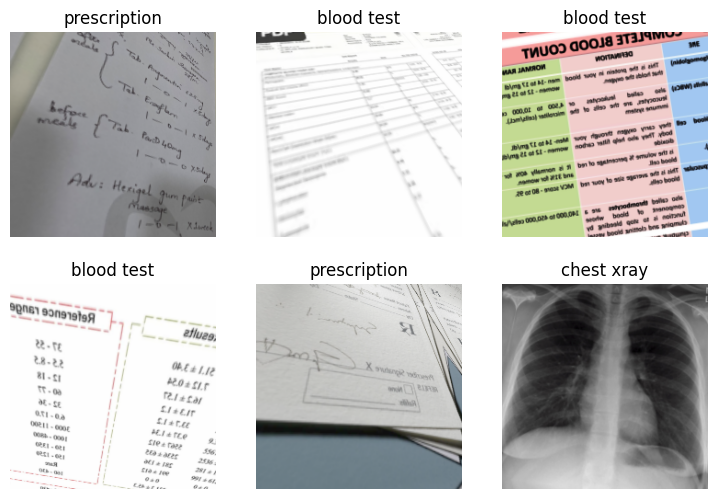

In [71]:
dls =DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(mult=2.0)
).dataloaders(path)

dls.show_batch(max_n=6)

**Train the model**

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(6)

epoch,train_loss,valid_loss,error_rate,time
0,2.346694,0.930414,0.303571,00:11


epoch,train_loss,valid_loss,error_rate,time
0,0.919629,0.377030,0.142857,00:08


**Clean bad images visually**

In [ ]:
from fastai.vision.widgets import *
cleaner = ImageClassifierCleaner(learn)
cleaner

**Actually delete the marked images**

In [ ]:
import shutil
for idx in cleaner.delete(): cleaner.fns[idx].unlink()
for idx, cat in cleaner.change(): shutil.move(str(cleaner.fns[idx]), path/cat)
print("Cleaning done!")

**Retrain after cleaning**

In [ ]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(mult=2.0)
).dataloaders(path)

learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(6)

**Save the model**

In [ ]:
learn.export('medical_classifier.pkl')
from google.colab import files
files.download('medical_classifier.pkl')
print("Model saved!")

**Test with a chest xray**

In [ ]:
is_type, _, probs = learn.predict(PILImage.create('chestxray.jpg'))
print(f"Model thinks this is: {is_type}")
print(f"--- All probabilities ---")
for category, prob in zip(learn.dls.vocab, probs):
    print(f"{category}: {prob:.4f}")

**Download and test an MRI image**

In [ ]:
from fastdownload import download_url
dest2 = 'test_mri.jpg'
mri_urls = search_images("brain MRI scan", max_images=5)
for url in mri_urls:
    try:
        download_url(url, dest2, show_progress=False)
        break
    except: continue
from fastai.vision.all import *
im = Image.open(dest2)
im.to_thumb(256,256)

**Run MRI through the model**

In [ ]:
is_type, _, probs = learn.predict(PILImage.create('test_mri.jpg'))
print(f"Model thinks this is: {is_type}")
print(f"--- All probabilities ---")
for category, prob in zip(learn.dls.vocab, probs):
    print(f"{category}: {prob:.4f}")

**Download and test a forest image**

In [ ]:
from fastdownload import download_url
dest3 = 'forest.jpg'
forest_urls = search_images("forest nature photo", max_images=5)
for url in forest_urls:
    try:
        download_url(url, dest3, show_progress=False)
        break
    except: continue
from fastai.vision.all import *
im = Image.open(dest3)
im.to_thumb(256,256)


**Run forest image through the model**

In [ ]:
is_type, _, probs = learn.predict(PILImage.create('forest.jpg'))

max_prob = probs.max().item()

if max_prob < 0.90:
    print("This doesn't look like a medical document!")
else:
    print(f"Model thinks this is: {is_type}")
    print(f"Confidence: {max_prob:.4f}")